## Example 2: Phase Kickback

### Purpose

This notebook example explores the phenomenon of Phase Kickback. This is an effect in which controlled gates can have an effect on their control qubits. It is an important building block in many quantum algorithms such as the Quantum Phase Estimation (QPE) and Shor's Algorithm.

### Imports and Definitions

The following Python imports will be needed:

In [1]:
from tinyqsim.qcircuit import QCircuit
import numpy as np
from math import pi
from cmath import exp

These Unicode definitions will be useful for annotating the quantum circuits:

In [2]:
U_PI = '\u03C0'  # Unicode pi
U_PHI = '\u03d5'  # Unicode phi
KET0 = '|0\u27E9' # Unicode ket |0>

### Introduction

Any unitary operator can be expressed in terms of the phases $\phi_k$ of its eigenvectors $\ket{u_k}$, as follows:

$$\qquad U=\sum_k{e^{i\phi_k}\,\ket{u_k}\bra{u_k}}$$

where $\lambda_k = e^{i\phi_k}$ are the corresponding eigenvalues.

The eigenvalue always has a magnitude of one because the operator is unitary, so it is just a phase term.

If we apply the unitary to one of its eigenvectors $\ket{u_k}$, the result will be the corresponding eigenvalue $e^{i\theta_k}$ multiplied by the eigenvector:

$$\qquad\begin{align*}
U \ket{u_k} &= ({e^{i\theta_k}\,\ket{u_k}\bra{\psi_k}})\ \ket{u_k}\\
&= e^{i\theta_k}\ket{u_k}
\end{align*}$$

Consider a unitary operator $U$ which has an eigenvector $\ket{u_k}$ with corresponding eigenvalue $e^{i\phi}$.

$$
U\ket{u_k} = e^{i\phi}\ket{u_k}
$$

We apply $U$ to its eigenstate as a controlled-U with the control in superposition:


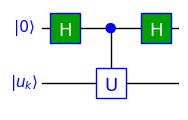

In [3]:
# Ignore this code. It is just used to draw a circuit diagram.
KET_U = fr'|$u_k$''\u27E9'
qc = QCircuit(2)
qc.qubit_labels({0: KET0, 1: KET_U}, numbers=False)
qc.h(0)
qc.cu(np.eye(2), 'U', 0, 1)
qc.h(0)
qc.draw()

The output is:

$$
{\small\frac{1}{\sqrt{2}}}(\ket{0}\ket{u_k} + \ket{1}U\ket{u_k}
$$

$$
= {\small\frac{1}{\sqrt{2}}}(\ket{0}\ket{u_k} + e^{i\phi}\ket{1}\ket{u_k}
$$

This is not an entangled state, because it can be written as the tensor product of qubit states:

$$
= ({\small\frac{1}{\sqrt{2}}}(\ket{0} + e^{i\phi}\ket{1})) \otimes\ket{u_k}
$$

The phase now appears on the control qubit.

Being able to do the factorization relies on the state $\ket{\psi}$ being an eigenstate of $U$. If this were not the case, the qubits would be entangled and it would not be meaningful to talk about their individual phases.

This effect is called "Phase Kickback". The phase resulting from a controlled gate is "kicked back" onto the control qubit and the target qubit is left unaffected. There were two things necessary to make this example work. The control input had to be in an equal superposition state and the target input had to be in an eigenvector of the controlled operation.

### Example

For a concrete example, we will use the following unitary matrix which has an eigenvector of $\ket{1}$ with corresponding eigenvalue $e^{\large i\frac{\pi}{3}}$.

$$
U=\begin{bmatrix}1&0\\0&e^{i\phi}\end{bmatrix},\quad\text{where }\phi=\frac{\pi}{3}
$$

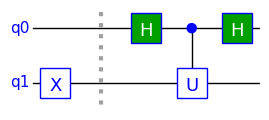

In [4]:
u = np.array([[1,0],[0,exp(1j * pi/3)]])

qc = QCircuit(2)
qc.x(1)
qc.barrier()
qc.h(0)
qc.cu(u, 'U', 0, 1)
qc.h(0)
qc.draw()

The $X$ gate initializes qubit q1 to $\ket{1}$, which is an eigenvector of $U$.

The output state is:

In [5]:
qc.display_state(prefix=r'\ket{\psi} = ')

<IPython.core.display.Math object>

This is not an entangled state, because it can be written as the tensor product of qubit states:

$$
\ket{\psi}=\left[(0.75+0.43301j)\ket{0}+(0.25-0.43301j)\ket{1}\right] \otimes\ket{1}
$$

All the phase has been kicked-back to qubit q0. Qubit q1 is still in its original state $\ket{1}$ and so has not been affected.

Phase kickback will work for any unitary, because a unitary simply applies a phase $\theta_k$ when its input is the corresonding eigenvector $\ket{\phi_k}$.

Although we have only considered a one-qubit unitary with two eigenvectors, it works for an N-qubit unitary with $2^N$ eigenvectors. By initializing the input of the unitary to one of its eigenvectors, we can read out the phase associated with the corresponding eigenvalue. This plays an important role in algorithms such as Quantum Phase Estimation (QPE).

### Understanding Controls

Phase Kickback may seem very strange, because we often think of the control of a controlled gate as an enabling input, such that a $\ket{1}$ on the control qubit enables the controlled operation on the target qubit and a $\ket{0}$ on the control causes the gate to have no effect. However, this is a misleading way to think about controlled gates. It is valid when the control is in the computational basis state, $\ket{0}$ or $\ket{1}$. However, when the control is in a superposition state, the output of the gate is a superposition of its its outputs for each of the basis states, but this may no longer behave like a simple control action.

For example, consider the following circuit with a controlled-X (CX) gate sandwiched between Hadamard gates. This "Hadamard Sandwich" changes the basis from Z to X before the CX gate and then back again afterwards.

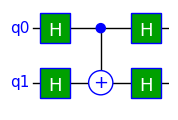

In [6]:
qc1 = QCircuit(2)
qc1.h([0,1])
qc1.cx(0,1)
qc1.h([0,1])
qc1.draw()

This is exactly equivalent to the following circuit, in which the roles of the control and target qubits are interchanged:

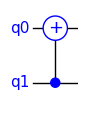

In [7]:
qc2 = QCircuit(2)
qc2.cx(1,0)
qc2.draw()

We can verify the equivalence by comparing the unitary matrices of the two circuits:

In [8]:
print(np.allclose(qc1.to_unitary(), qc2.to_unitary()))

True


The "Hadamard sandwich" effectively changes the basis from Z to X. This has the effect of reversing the roles of the control and target qubits. So, the concept of a particular qubit of a gate being the control is dependent on the basis.

For controlled gates that have a diagonal unitary matrix, such as CP and CZ, it is actually arbitary which qubit we regard as the control because of symmetry. These are often represented by a symmetrical symbol, such as the CZ in the following circuit.

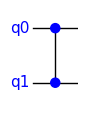

In [9]:
qc = QCircuit(2)
qc.cz(0,1)
qc.draw()

In our earlier example, we used the following controlled unitary to demonstrate phase kickback:

$$
U=\begin{bmatrix}1&0\\0&e^{i\phi}\end{bmatrix},\quad\text{where }\phi=\frac{\pi}{3}
$$

Since this was a diagonal matrix, the gate was symmtrical and we could have drawn the circuit as follows:

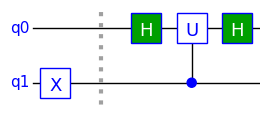

In [10]:
qc = QCircuit(2)
qc.x(1)
qc.barrier()
qc.h(0)
qc.cu(u, 'U', 1, 0)
qc.h(0)
qc.draw()

The control is enabled because of the $X$ gate, so the circuit just reduces to an un-controlled $U$ gate sandwiched between two Hadamard gates. However, as shown above in the introduction, phase kickback works more generally with any controlled unitary and does not require a diagonal matrix.

### Application

Later example notebooks show how phase kickbck may be used to implement Quantum Phase Estimation and that this can, in turn, be used to implement Shor's algorithm.